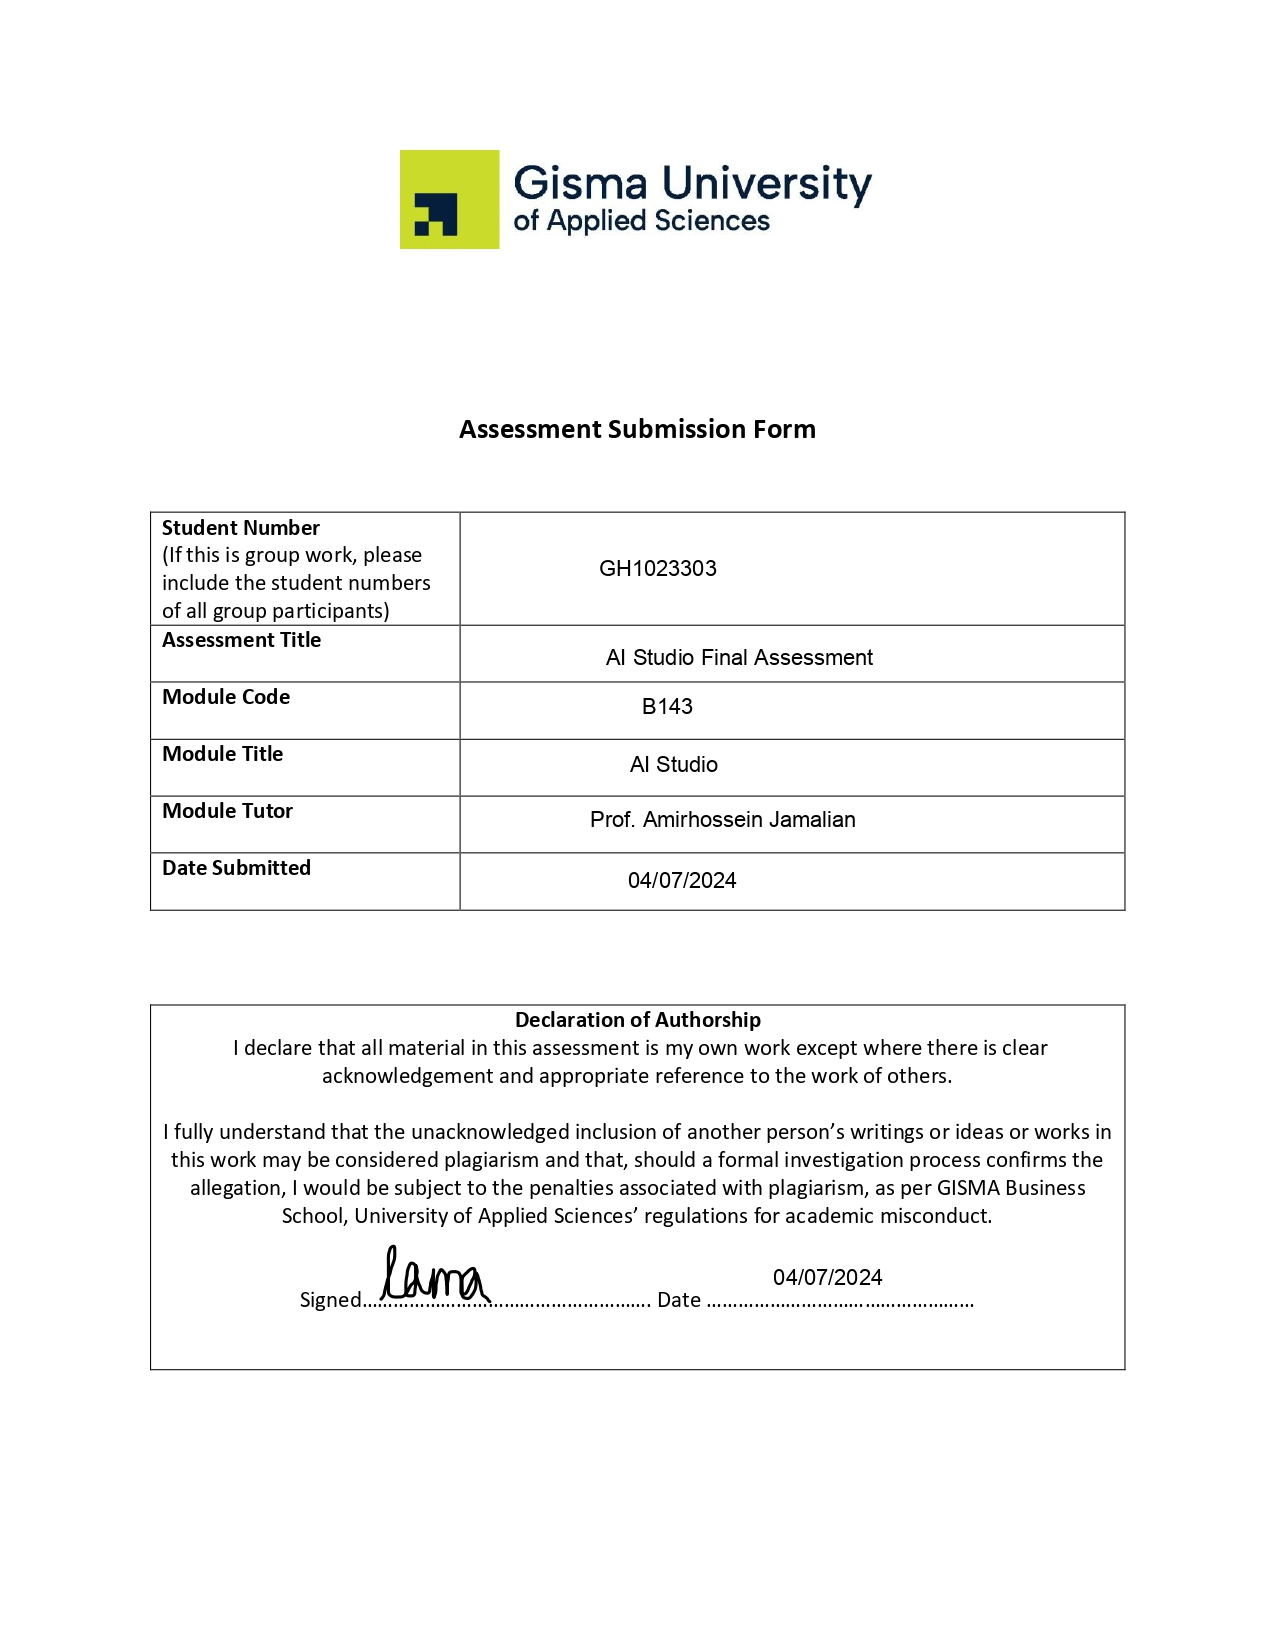

In [3]:
from IPython.display import Image 
Image(filename =('AI Assessment Submission Form_page-0001.jpg'))

# **Uncleaned Bike Sales Dataset**
The [dataset](https://www.kaggle.com/datasets/ratnarohith/uncleaned-bike-sales-data/data) I have used in my project is an uncleaned table that includes information about customers and a bike that they purchased on a specific day in December.

**Project Goal:**
The analysis of this dataset is useful for the business because it can help the business better understand the performance of bikes sales and customer behaviour as well as the relationship between different features within the dataset. An example of some questions that will be answered in this project include: What is the correlation between different features such as Customer Age and Bike price? How can we calculate and predict Profit? When does the business make the most Profit?

I will be cleaning this dataset and applying some machine learning algorithms to make predictions about and compare their efficiencies and performance using metrics like accuracy, Precision and recall.

**Contents:**


1.   Data observation and Description
2.   Data Cleaning
3.   Preprocessing and binarization
5.   Correlation Analysis
6.   Tsetlin Machine Implementation
7.   Random Forest and Logistic Regression
8.   Model comparisons
9.   Conclusion




In [ ]:
file:///C:/Users/lamat/Downloads/AI%20Assessment%20Submission%20Form.pdf 


The column descriptions are available here:
Shahriarkabir (2024) Data Cleaning + Eda, Kaggle. Available at: https://www.kaggle.com/code/shahriarkabir/data-cleaning-eda (Accessed: 01 July 2024).

In [1]:
#Installing the necessary Tsetlin Machine packages
!pip install PyTsetlinMachine


  Preparing metadata (setup.py) ... done
  Created wheel for PyTsetlinMachine: filename=pyTsetlinMachine-0.6.6-cp310-cp310-linux_x86_64.whl size=59496 sha256=bbc8cb8354531b852dfc16d18e5e8448de52b161bee8d6a5b6018c6935f5a132
  Stored in directory: /root/.cache/pip/wheels/b0/b0/c5/07c4cb8bb93c5325bdc2c2a070b565f54df717d5d11f0c6802
Successfully built PyTsetlinMachine


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pyTsetlinMachine.tm import MultiClassTsetlinMachine
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [12]:
#reading the dataset(an excel file in this case) and loading it in as a dataframe
df1 = pd.read_excel('uncleaned bike sales data.xlsx')

df1.isnull().any()#finding any columns with null values

Sales_Order #          False
Date                   False
Day                     True
Month                  False
Year                   False
Customer_Age           False
Age_Group               True
Customer_Gender        False
Country                False
State                  False
Product_Category       False
Sub_Category           False
Product_Description     True
Order_Quantity          True
 Unit_Cost             False
 Unit_Price            False
 Profit                False
 Cost                  False
Revenue                False
dtype: bool

The result above shows that the following columns have null values:

Day,  Age_Group, Product_Description, Order_Quantity

In [4]:
print(df1.columns)

Index(['Sales_Order #', 'Date', 'Day', 'Month', 'Year', 'Customer_Age',
       'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product_Description', 'Order_Quantity', ' Unit_Cost ',
       ' Unit_Price ', ' Profit ', ' Cost ', 'Revenue'],
      dtype='object')


displaying all columns present in the table

In [5]:
#finding and removing duplicates
df1.duplicated().sum()

0

After running the duplicates command in order to identify any repeated values. We get 0 as a result, which means the dataset does not contain any duplicates.

## **Nulls and Zeroes**

In [6]:
#finding rows with 0.00 as their value
is_zero = df1.eq(0.00)

zero_rows = is_zero.any(axis=1)#function to find zero values

zero_values_df = df1[zero_rows]#finding the zero value containing rows from our dataset

print("zero values in df1:")
print(zero_values_df)

zero values in df1:
    Sales_Order #       Date  Day     Month  Year  Customer_Age  \
4          261699 2021-12-03  3.0  December  2021            37   
8          261702 2021-12-04  4.0  December  2021            31   
22         261716 2021-12-08  8.0  December  2021            35   

               Age_Group Customer_Gender         Country            State  \
4         Adults (35-64)               F  United  States       California   
8   Young Adults (25-34)               F       Australia  New South Wales   
22        Adults (35-64)               F   United States       California   

   Product_Category    Sub_Category        Product_Description  \
4             Bikes  Mountain Bikes     Mountain-200 Black, 46   
8             Bikes  Mountain Bikes  Mountain-400-W Silver, 42   
22            Bikes  Mountain Bikes     Mountain-500 Black, 42   

    Order_Quantity   Unit_Cost    Unit_Price    Profit    Cost   Revenue  
4              2.0            0          2295      2086       

In [7]:
#finding the specific null rows
null_rows = df1[df1.isnull().any(axis=1)]
print(null_rows)

    Sales_Order #       Date  Day     Month  Year  Customer_Age  \
10         261704 2021-12-05  NaN  December  2021            42   
15         261709 2021-12-06  6.0  December  2021            36   
21         261715 2021-12-08  8.0  December  2021            39   
22         261716 2021-12-08  8.0  December  2021            35   

         Age_Group Customer_Gender        Country                State  \
10  Adults (35-64)               M        Germany  Nordrhein-Westfalen   
15             NaN               M      Australia      New South Wales   
21  Adults (35-64)               F  United States               Oregon   
22  Adults (35-64)               F  United States           California   

   Product_Category    Sub_Category     Product_Description  Order_Quantity  \
10            Bikes  Mountain Bikes  Mountain-200 Black, 38             4.0   
15            Bikes  Mountain Bikes  Mountain-200 Black, 42             1.0   
21            Bikes  Mountain Bikes                     

When examining the dataset and identifying the null values and zeroes, we find that there are some values that we can manually fill in using other information from columns within the table; therefore, I started by filling in some of these values manually.

In [8]:
#Manually filling null values
df1.at[4, 'Unit_Cost'] = '$1,252.00' #I analysed other columns and find out this information based on data related to the bike

df1.at[8, 'Unit_Price'] = '$769.00' #I analysed other columns and find out this information based on data related to the bike

df1.at[10, 'Day'] = 5.0  # We found the day from the date column

df1.at[15, 'Age_Group'] = 'Adults (35-64)' # We found the age group from the age column

df1.at[21, 'Product_Description'] = 'Mountain-200 Black, 38' #Since we do not have enough info to know which exact bike this customer bought. I calculated the most commonly bought bike by females in the US to get the most probable bike that this customer bought + we know that it is not silver bike's price so I put black,38

In [9]:
#checking that values were successfully added
df1.head(20)

,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,261695,2021-12-01,1.0,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4.0,1252,2295,4172,5008,9180
1,261695,2021-12-01,1.0,December,2021,44,Adults (35-64),M,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1.0,1266,2320,1054,1266,2320
2,261697,2021-12-02,2.0,December,2021,37,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-400-W Silver, 46",2.0,420,769,698,840,1538
3,261698,2021-12-02,2.0,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",1.0,420,769,349,420,769
4,261699,2021-12-03,3.0,December,2021,37,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2.0,0,2295,2086,0,4590
5,261700,2021-12-03,3.0,December,2021,24,Youth (<25),F,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Black, 38",1.0,1252,2295,1043,1252,2295
6,261701,2021-12-03,3.0,December,2021,37,Adults (35-64),M,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Black, 46",1.0,1252,2295,1043,1252,2295
7,261701,2021-12-03,3.0,December,2021,37,Adults (35-64),M,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Black, 46",1.0,1252,2295,1043,1252,2295
8,261702,2021-12-04,4.0,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",4.0,420,0,1396,1680,0
9,261703,2021-12-05,5.0,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4.0,1252,2295,4172,5008,9180


In [11]:
#This cell shows how I calculated the most commonly bought bike aka the value I used in the cell above
# Filtering the data for females from the US
FUS_df = df1[(df1['Country'] == 'United States') & (df1['Customer_Gender'] == 'F')]

# Count the no. of purchases per bike
total_bikes = FUS_df['Product_Description'].value_counts()

# Get the most bought bike using the max function
most_bought_bike = total_bikes.idxmax()
most_bought_bike_count =  total_bikes.max()

print(f"The most bought bike by females from the US is: {most_bought_bike}")

The most bought bike by females from the US is: Mountain-200 Silver, 38


For values where it is difficult to manually fill them in like: Revenue and cost, and where creating a function would be easier and more accurate, I defined a function 'fill_null_values'to perform some mathematical operations that will calculate Revenue and Cost; additionally, these columns contain different data types. Some like Unit_price are strings and some are numerical, like Order_Quantity so, we must convert all the non-numeric columns to numeric or integers, which is why I defined another function to convert all the data to numerical.
I used LabelEncoder from sklearn to facilitate this process.

In [10]:
def cols_numeric(df1):
  # Convert non-numeric columns to numeric by LabelEncoder
  label_encoders = {}
  for column in df1.select_dtypes(include=['object']).columns:
        label_encoders[column] = LabelEncoder()
        df1[column] = label_encoders[column].fit_transform(df1[column])

  #Specifying the columns  (each line below individually converts the non-numerical columns to numerical)
        df1['Order_Quantity'] = pd.to_numeric(df1['Order_Quantity'])
        df1['Unit_Cost'] = pd.to_numeric(df1['Unit_Cost'])
        df1['Unit_Price'] = pd.to_numeric(df1['Unit_Price'])
        df1['Cost'] = pd.to_numeric(df1['Cost'])
        df1['Revenue'] = pd.to_numeric(df1['Revenue'])

  return df1

In [11]:
#Filling null and zero values
def fill_null_values(df1):
  df1.loc[df1['Revenue'] == 0, 'Revenue'] = df1['Unit_Price'] * df1['Order_Quantity']#multiplying unit price and order quantity to compute revenue (I figured this out based on other values within the table)
  df1.loc[df1['Cost'] == 0, 'Cost'] = df1['Unit_Cost'] * df1['Order_Quantity']#multiplying unit cost and order quantity to compute cost
  return df1

In [12]:
#checking the functions were executed successfully
df1.head(20)

,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,261695,2021-12-01,1.0,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4.0,1252,2295,4172,5008,9180
1,261695,2021-12-01,1.0,December,2021,44,Adults (35-64),M,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1.0,1266,2320,1054,1266,2320
2,261697,2021-12-02,2.0,December,2021,37,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-400-W Silver, 46",2.0,420,769,698,840,1538
3,261698,2021-12-02,2.0,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",1.0,420,769,349,420,769
4,261699,2021-12-03,3.0,December,2021,37,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2.0,0,2295,2086,0,4590
5,261700,2021-12-03,3.0,December,2021,24,Youth (<25),F,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Black, 38",1.0,1252,2295,1043,1252,2295
6,261701,2021-12-03,3.0,December,2021,37,Adults (35-64),M,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Black, 46",1.0,1252,2295,1043,1252,2295
7,261701,2021-12-03,3.0,December,2021,37,Adults (35-64),M,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Black, 46",1.0,1252,2295,1043,1252,2295
8,261702,2021-12-04,4.0,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",4.0,420,0,1396,1680,0
9,261703,2021-12-05,5.0,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4.0,1252,2295,4172,5008,9180


The above code could be used for cleaning, I included it to show we could possibly clean the datset but it did not work with me in spite many attempts and adjustments, and it was taking a lot of time, so I'm using the ready cleaned dataset for the algorithm application and visualizations.

In [13]:
#reading the dataset
df_clean = pd.read_csv('bike_sales_data_clean.csv')
df_clean.head(10)

,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,...,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Product_Name,Product_Color,Product_Size
0,261695,2021-12-01,1,December,2021,39,Adults (35-64),F,United States,California,...,"Mountain-200 Black, 46",4.0,1252,2295,4172,5008,9180,Mountain-200,Black,46
1,261695,2021-12-01,1,December,2021,44,Adults (35-64),M,United Kingdom,England,...,"Mountain-200 Silver, 42",1.0,1266,2320,1054,1266,2320,Mountain-200,Silver,42
2,261697,2021-12-02,2,December,2021,37,Adults (35-64),M,United States,California,...,"Mountain-400-W Silver, 46",2.0,420,769,698,840,1538,Mountain-400-W,Silver,46
3,261698,2021-12-02,2,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,...,"Mountain-400-W Silver, 42",1.0,420,769,349,420,769,Mountain-400-W,Silver,42
4,261699,2021-12-03,3,December,2021,37,Adults (35-64),F,United States,California,...,"Mountain-200 Black, 46",2.0,1252,2295,2086,2504,4590,Mountain-200,Black,46
5,261700,2021-12-03,3,December,2021,24,Youth (<25),F,United Kingdom,England,...,"Mountain-200 Black, 38",1.0,1252,2295,1043,1252,2295,Mountain-200,Black,38
6,261701,2021-12-03,3,December,2021,37,Adults (35-64),M,United States,Washington,...,"Mountain-200 Black, 46",1.0,1252,2295,1043,1252,2295,Mountain-200,Black,46
7,261701,2021-12-03,3,December,2021,37,Adults (35-64),M,United States,Washington,...,"Mountain-200 Black, 46",1.0,1252,2295,1043,1252,2295,Mountain-200,Black,46
8,261702,2021-12-04,4,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,...,"Mountain-400-W Silver, 42",4.0,420,769,1396,1680,3076,Mountain-400-W,Silver,42
9,261703,2021-12-05,5,December,2021,39,Adults (35-64),F,United States,California,...,"Mountain-200 Black, 46",4.0,1252,2295,4172,5008,9180,Mountain-200,Black,46


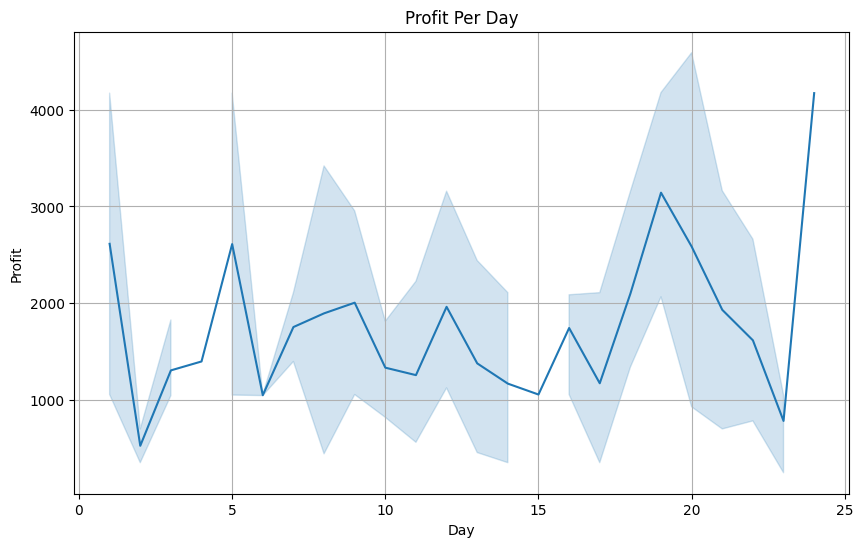

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x='Day', y='Profit')

plt.xlabel('Day')
plt.ylabel('Profit')
plt.title('Profit Per Day')
plt.grid(True)

plt.show()

## Gender Binarization
I got worse results with the machine models when I ran this code, so I am including it but not running it on the main dataset and I stored the results elsewhere. I did, however, run encoding separately again when testing and training later in the Tsetlin Machine models and that was much more efficient.

In [3]:
#using encoding to binarize the data to 1 and 0, and convert the data to a form that algorithms can easily use
data = pd.read_csv('bike_sales_data_clean.csv')
data['Customer_Gender_Binary'] = data['Customer_Gender'].map({'Male': 1, 'Female': 0})
categorical_columns = data.select_dtypes(include=['object']).columns#converting categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
print(data_encoded.head())
print(data_encoded.dtypes)

   Sales_Order #  Day  Year  Customer_Age  Order_Quantity  Unit_Cost  \
0         261695    1  2021            39             4.0       1252   
1         261695    1  2021            44             1.0       1266   
2         261697    2  2021            37             2.0        420   
3         261698    2  2021            31             1.0        420   
4         261699    3  2021            37             2.0       1252   

   Unit_Price  Profit  Cost  Revenue  ...  \
0        2295    4172  5008     9180  ...   
1        2320    1054  1266     2320  ...   
2         769     698   840     1538  ...   
3         769     349   420      769  ...   
4        2295    2086  2504     4590  ...   

   Product_Description_Mountain-500 Black, 40  \
0                                       False   
1                                       False   
2                                       False   
3                                       False   
4                                       False   

 

Correlation matrix and Analysis

In [4]:
columns = ['Customer_Gender_Binary'] + [col for col in data_encoded.columns if col != 'Customer_Gender_Binary']
columns = ['Customer_Gender_Binary', 'Customer_Age', 'Order_Quantity', 'Unit_Price', 'Day']

data_selected = data_encoded[columns]
correlation_matrix = data_selected.corr()
print(correlation_matrix)


                        Customer_Gender_Binary  Customer_Age  Order_Quantity  \
Customer_Gender_Binary                     NaN           NaN             NaN   
Customer_Age                               NaN      1.000000       -0.014774   
Order_Quantity                             NaN     -0.014774        1.000000   
Unit_Price                                 NaN      0.271184       -0.035585   
Day                                        NaN     -0.104785        0.123860   

                        Unit_Price       Day  
Customer_Gender_Binary         NaN       NaN  
Customer_Age              0.271184 -0.104785  
Order_Quantity           -0.035585  0.123860  
Unit_Price                1.000000  0.036340  
Day                       0.036340  1.000000  


The results of the correlation calculations show that features like Unit_Price and Customer_Age have a slight correlartion, which could mean for example, that older customers buy more expensive bikes. On the other hand, Customer_Age and Unit_Price have have a negative correlation with Order_Quantity, which makes sense because buying a more expensive bike would probably also mean that the customer is not buying large quantities.

## One hot Encoding and Test & Train

In [14]:
df_clean = pd.read_csv('bike_sales_data_clean.csv')
# Find categorical columns
categ_cols = df_clean.select_dtypes(include=['object']).columns

# One-hot encoding
encoder = OneHotEncoder(sparse=False, drop='first')
encoded_cols = encoder.fit_transform(df_clean[categ_cols])

# Create a DataFrame with encoded columns
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categ_cols))

# Combine encoded columns with original numeric columns
data_encoded = df_clean.drop(columns=categ_cols).join(encoded_df)

# Separate features and target variable
X = data_encoded.drop(columns=['Profit'])  # Features
y = data_encoded['Profit']  # Target

# Split data into training and testing sets
# Note: You can try different random_state values, e.g., 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## Tsetlin Machine

In [18]:
# Initialize Tsetlin Machine
# Note: Experiment with different values to find optimal parameters
tm = MultiClassTsetlinMachine(number_of_clauses=100, T=10, s=2.0)

# Binarize features for train and test sets
# Using mean as threshold, could try median or other thresholds
X_train_binary = (X_train > X_train.mean()).astype(int)
X_test_binary = (X_test > X_test.mean()).astype(int)

# Train the model
print(" Tsetlin Machine Training")
tm.fit(X_train_binary.values, y_train.values, epochs=10)

# Make predictions
print("predictions:")
y_pred = tm.predict(X_test_binary.values)

# Evaluate TM performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Using macro average (unweighted mean) for multi-class
precision = precision_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.4f}")
#Recall
recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall: {recall:.4f}")
#F1-score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1-score: {f1:.4f}")

 Tsetlin Machine Training
predictions:
Accuracy: 0.2778
Precision: 0.0298
Recall: 0.0833
F1-score: 0.0439


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [19]:
# Initialize Tsetlin Machine
# Note: Experiment with different values to find optimal parameters
tm = MultiClassTsetlinMachine(number_of_clauses= 50, T=10, s=2.0)

# Binarize features for train and test sets
# Using mean as threshold, could try median or other thresholds
X_train_binary = (X_train > X_train.mean()).astype(int)
X_test_binary = (X_test > X_test.mean()).astype(int)

# Train the model
print(" Tsetlin Machine Training")
tm.fit(X_train_binary.values, y_train.values, epochs=10)

# Make predictions
print("predictions:")
y_pred = tm.predict(X_test_binary.values)

# Evaluate TM performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Using macro average (unweighted mean) for multi-class
precision = precision_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.4f}")
#Recall
recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall: {recall:.4f}")
#F1-score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1-score: {f1:.4f}")

 Tsetlin Machine Training
predictions:
Accuracy: 0.3889
Precision: 0.2708
Recall: 0.2833
F1-score: 0.2476


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Random Forest

In [10]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=44)

#Model Training
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Model Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

precision_rf = precision_score(y_test, y_pred_rf, average='macro')
print("Precision:", precision_rf)

recall_rf = recall_score(y_test, y_pred_rf, average='macro')
print("Recall:", recall_rf)

f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f'F1 Score:', f1_rf)

Accuracy: 0.8333333333333334
Precision: 0.6
Recall: 0.6
F1 Score: 0.6


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [20]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=44)#through several trials these were some of the optimal values for n_estimators and random_state

#Model Training
rf.fit(X_train, y_train)

#Predict
y_pred_rf = rf.predict(X_test)

#Model Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

precision_rf = precision_score(y_test, y_pred_rf, average='macro')
print("Precision:", precision_rf)

recall_rf = recall_score(y_test, y_pred_rf, average='macro')
print("Recall:", recall_rf)

f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f'F1 Score:', f1_rf)

Accuracy: 0.8333333333333334
Precision: 0.6
Recall: 0.6
F1 Score: 0.6


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Logistic Regression

In [11]:
#Logistic Regression
lr = LogisticRegression(max_iter=100, random_state=44)

# Train the model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print('Accuracy:', accuracy_lr)

precision_lr = precision_score(y_test, y_pred_lr, average='macro')
print('Precision:', precision_lr)

recall_lr = recall_score(y_test, y_pred_lr, average='macro')
print('Recall:', recall_lr)

f1_lr = f1_score(y_test, y_pred_lr, average='macro')
print('F1 Score:', f1_lr)

Accuracy: 0.5
Precision: 0.375
Recall: 0.5384615384615384
F1 Score: 0.4265734265734266


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_

## **Model Comparisons**

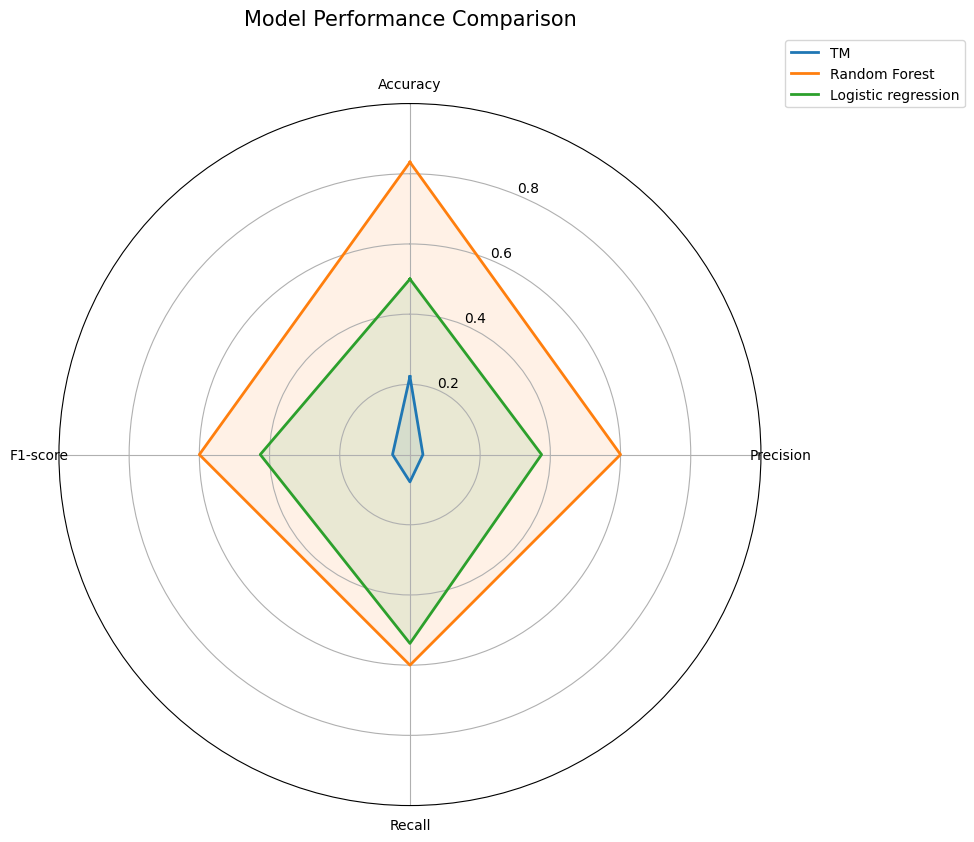

In [17]:
# model performance data
models = ['TM', 'Random Forest', 'Logistic regression']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = np.array([
    [0.2222, 0.037, 0.0778, 0.0496],  # TM
    [0.833, 0.6, 0.6, 0.6],  # RandomForest
    [0.5, 0.375, 0.538, 0.4265],  # Logistic regression
])

# Set up the radar chart
num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False)


angles = np.concatenate((angles, [angles[0]]))#Closing the plot by appending the first value to the end

# building the plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

#Plot each model
for i, model in enumerate(models):
    model_values = np.concatenate((values[i], [values[i][0]]))
    ax.plot(angles, model_values, linewidth=2, label=model)
    ax.fill(angles, model_values, alpha=0.1)

#specifications of the chart
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'])

#legend and title
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Model Performance Comparison', fontsize=15, y=1.1)

plt.tight_layout()
plt.show()

## **Conclusion**

After cleaning, preprocessing and performing some feature engineering and running the code of all the machine learning models, I put all the metrics of measurement for each model and I put them in a list with the different model names in order to compare between them and find out which one has performed the best for this dataset.
As is clear by the accuracy, precision, and recall metrics the model with the best overall performance is Random Forest, the second best is Logistic Regression and the worst with the lowest values (by quite a margin) is The Tsetlin Machine. It would be most appropriate to use Random Forest, especially considering that it's accuracy in this case is around 0.83 or 83%.